In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.spatial.distance import cdist

# Merge years

In [8]:
PT_FILES = '/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/spatial data/wytham/RFID_DATA'

In [28]:
# Make pandas display wider in this notebook
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [9]:
df_locations = pd.read_csv(f'{PT_FILES}/logger_locations.csv')
# 2012
# df = pd.read_csv(f'{PT_FILES}/2012/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2012/ids.csv')
# 2013
# df = pd.read_csv(f'{PT_FILES}/2013/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2013/ids.csv')
# 2014
# df = pd.read_csv(f'{PT_FILES}/2014/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2014/ids.csv')
# 2015
# df = pd.read_csv(f'{PT_FILES}/2015/records.csv')
# df_ids = pd.read_csv(f'{PT_FILES}/2015/ids.csv')
df = pd.DataFrame()
for i in range (2012,2016):
    df_temp = pd.read_csv(f'{PT_FILES}/{i}/records.csv')
    df_ids_temp = pd.read_csv(f'{PT_FILES}/{i}/ids.csv')
    df_temp = df_temp.join(df_ids_temp.set_index('id'), on='id', rsuffix='_id')
    df = pd.concat([df, df_temp], ignore_index=True)
df.drop(columns='antenna_number', inplace=True)

In [11]:
# Convert time to datetime once
if 'time_dt' not in df.columns:
    df['time_dt'] = pd.to_datetime(df['time'], errors='coerce')
    df.drop(columns='time', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25765956 entries, 0 to 25765955
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   id         object        
 1   location   object        
 2   species    object        
 3   sex        object        
 4   age        object        
 5   immigrant  bool          
 6   time_dt    datetime64[ns]
dtypes: bool(1), datetime64[ns](1), object(5)
memory usage: 1.2+ GB


In [12]:
print(df['id'].nunique())

6251


In [ ]:
df_process = df.dropna(subset=['time_dt']).sort_values(['id', 'time_dt']).copy()#grouop by id and datetime
df_process=df_process.reset_index(drop=True)#reset index to go by id and datetime

In [ ]:
df_process['time_diff'] = df_process.groupby('id')['time_dt'].diff().dt.total_seconds()
# compare location within the same id
loc_changed = df_process['location'].ne(df_process.groupby('id')['location'].shift())

# new visit if location changed
df_process['is_new_visit'] = loc_changed.fillna(False)
# arrivial is a new visit or first record for id
df_process['is_arrival'] = df_process['is_new_visit']# | (df_process.groupby('id').cumcount() == 0)

# do the next-visit shift within each id to avoid cross-id leakage
df_process['is_departure'] = (
    df_process.groupby('id')['is_new_visit'].shift(-1, fill_value=True)#if next record is arrival
    | (df_process.groupby('id').cumcount(ascending=False) == 0)#or if this is the last record for that id
)

In [ ]:
df_process.head(11)

,id,location,species,sex,age,immigrant,time_dt,time_diff,is_new_visit,is_arrival,is_departure
0,c695905,1c,bluti,M,ad,False,2011-12-03 08:34:37,NaN,True,True,False
1,c695905,1c,bluti,M,ad,False,2011-12-03 08:34:38,1.0,False,False,False
2,c695905,1c,bluti,M,ad,False,2011-12-03 08:35:11,33.0,False,False,False
3,c695905,1c,bluti,M,ad,False,2011-12-03 08:35:12,1.0,False,False,False
4,c695905,1c,bluti,M,ad,False,2011-12-03 08:38:14,182.0,False,False,False
5,c695905,1c,bluti,M,ad,False,2011-12-03 08:38:15,1.0,False,False,False
6,c695905,1c,bluti,M,ad,False,2011-12-03 08:39:18,63.0,False,False,False
7,c695905,1c,bluti,M,ad,False,2011-12-03 08:39:19,1.0,False,False,False
8,c695905,1c,bluti,M,ad,False,2011-12-03 09:04:49,1530.0,False,False,False
9,c695905,1c,bluti,M,ad,False,2011-12-03 09:04:50,1.0,False,False,True


In [ ]:
df_visits = df_process[df_process['is_arrival'] | df_process['is_departure']].copy() # keep only arrivals and departures
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 237998 entries, 0 to 25765955
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            237998 non-null  object        
 1   location      237998 non-null  object        
 2   species       237998 non-null  object        
 3   sex           237998 non-null  object        
 4   age           237998 non-null  object        
 5   immigrant     237998 non-null  bool          
 6   time_dt       237998 non-null  datetime64[ns]
 7   time_diff     231747 non-null  float64       
 8   is_new_visit  237998 non-null  bool          
 9   is_arrival    237998 non-null  bool          
 10  is_departure  237998 non-null  bool          
dtypes: bool(4), datetime64[ns](1), float64(1), object(5)
memory usage: 15.4+ MB


In [ ]:
df_visits.head(11)

,id,location,species,sex,age,immigrant,time_dt,time_diff,is_new_visit,is_arrival,is_departure
0,c695905,1c,bluti,M,ad,False,2011-12-03 08:34:37,NaN,True,True,False
9,c695905,1c,bluti,M,ad,False,2011-12-03 09:04:50,1.0,False,False,True
10,c695905,1d,bluti,M,ad,False,2011-12-03 09:48:51,2641.0,True,True,False
97,c695905,1d,bluti,M,ad,False,2011-12-04 10:57:23,994.0,False,False,True
98,c695905,1c,bluti,M,ad,False,2011-12-04 11:22:51,1528.0,True,True,False
194,c695905,1c,bluti,M,ad,False,2011-12-10 11:00:26,1.0,False,False,True
195,c695905,1d,bluti,M,ad,False,2011-12-10 11:15:12,886.0,True,True,False
232,c695905,1d,bluti,M,ad,False,2011-12-11 10:57:17,173.0,False,False,True
233,c695905,1c,bluti,M,ad,False,2011-12-11 11:24:15,1618.0,True,True,False
280,c695905,1c,bluti,M,ad,False,2011-12-11 15:39:59,1.0,False,False,True


In [ ]:
df_visits['prev_time_dt'] = df_visits.groupby('id')['time_dt'].shift(1)
df_visits['same_day'] = df_visits['time_dt'].dt.date == df_visits['prev_time_dt'].dt.date#check if same day as previous record for that id
print(df_visits.head(11))


          id location species sex age  immigrant             time_dt  time_diff  is_new_visit  is_arrival  is_departure        prev_time_dt  same_day
0    c695905       1c   bluti   M  ad      False 2011-12-03 08:34:37        NaN          True        True         False                 NaT     False
9    c695905       1c   bluti   M  ad      False 2011-12-03 09:04:50        1.0         False       False          True 2011-12-03 08:34:37      True
10   c695905       1d   bluti   M  ad      False 2011-12-03 09:48:51     2641.0          True        True         False 2011-12-03 09:04:50      True
97   c695905       1d   bluti   M  ad      False 2011-12-04 10:57:23      994.0         False       False          True 2011-12-03 09:48:51     False
98   c695905       1c   bluti   M  ad      False 2011-12-04 11:22:51     1528.0          True        True         False 2011-12-04 10:57:23      True
194  c695905       1c   bluti   M  ad      False 2011-12-10 11:00:26        1.0         False       

In [44]:
df_visits = df_visits[df_visits['same_day'] | df_visits['prev_time_dt'].isna() | df_visits['is_departure']].copy()#keep only same day or first record for that id
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201918 entries, 0 to 25765955
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            201918 non-null  object        
 1   location      201918 non-null  object        
 2   species       201918 non-null  object        
 3   sex           201918 non-null  object        
 4   age           201918 non-null  object        
 5   immigrant     201918 non-null  bool          
 6   time_dt       201918 non-null  datetime64[ns]
 7   time_diff     195667 non-null  float64       
 8   is_new_visit  201918 non-null  bool          
 9   is_arrival    201918 non-null  bool          
 10  is_departure  201918 non-null  bool          
 11  prev_time_dt  195667 non-null  datetime64[ns]
 12  same_day      201918 non-null  bool          
dtypes: bool(5), datetime64[ns](2), float64(1), object(5)
memory usage: 14.8+ MB


In [47]:
df_visits.head(11)

,id,location,species,sex,age,immigrant,time_dt,time_diff,is_new_visit,is_arrival,is_departure,prev_time_dt,same_day
0,c695905,1c,bluti,M,ad,False,2011-12-03 08:34:37,NaN,True,True,False,NaT,False
9,c695905,1c,bluti,M,ad,False,2011-12-03 09:04:50,1.0,False,False,True,2011-12-03 08:34:37,True
10,c695905,1d,bluti,M,ad,False,2011-12-03 09:48:51,2641.0,True,True,False,2011-12-03 09:04:50,True
97,c695905,1d,bluti,M,ad,False,2011-12-04 10:57:23,994.0,False,False,True,2011-12-03 09:48:51,False
98,c695905,1c,bluti,M,ad,False,2011-12-04 11:22:51,1528.0,True,True,False,2011-12-04 10:57:23,True
194,c695905,1c,bluti,M,ad,False,2011-12-10 11:00:26,1.0,False,False,True,2011-12-04 11:22:51,False
195,c695905,1d,bluti,M,ad,False,2011-12-10 11:15:12,886.0,True,True,False,2011-12-10 11:00:26,True
232,c695905,1d,bluti,M,ad,False,2011-12-11 10:57:17,173.0,False,False,True,2011-12-10 11:15:12,False
233,c695905,1c,bluti,M,ad,False,2011-12-11 11:24:15,1618.0,True,True,False,2011-12-11 10:57:17,True
280,c695905,1c,bluti,M,ad,False,2011-12-11 15:39:59,1.0,False,False,True,2011-12-11 11:24:15,True


In [49]:
# count how many departures there are
num_departures = df_visits['is_departure'].sum()
num_departures


np.int64(120618)

# plots

In [27]:
species_order = sorted(df['species'].dropna().unique())
cmap = plt.get_cmap('tab10')
species_color = {sp: cmap(i % 10) for i, sp in enumerate(species_order)}
# aggregations
loc_counts = df['location'].value_counts()
id_counts = df['id'].value_counts()
# 1) Records per ID, colored by species
id_counts_df = (
    id_counts.rename('records')
    .reset_index()
    .merge(df[['id', 'species']], on='id', how='left')
)

hours = df['time_dt'].dropna().dt.hour.value_counts().sort_index()
daily = (
    df.dropna(subset=['time_dt'])
    .groupby(pd.Grouper(key='time_dt', freq='D'))
    .size()
)



KeyboardInterrupt: 

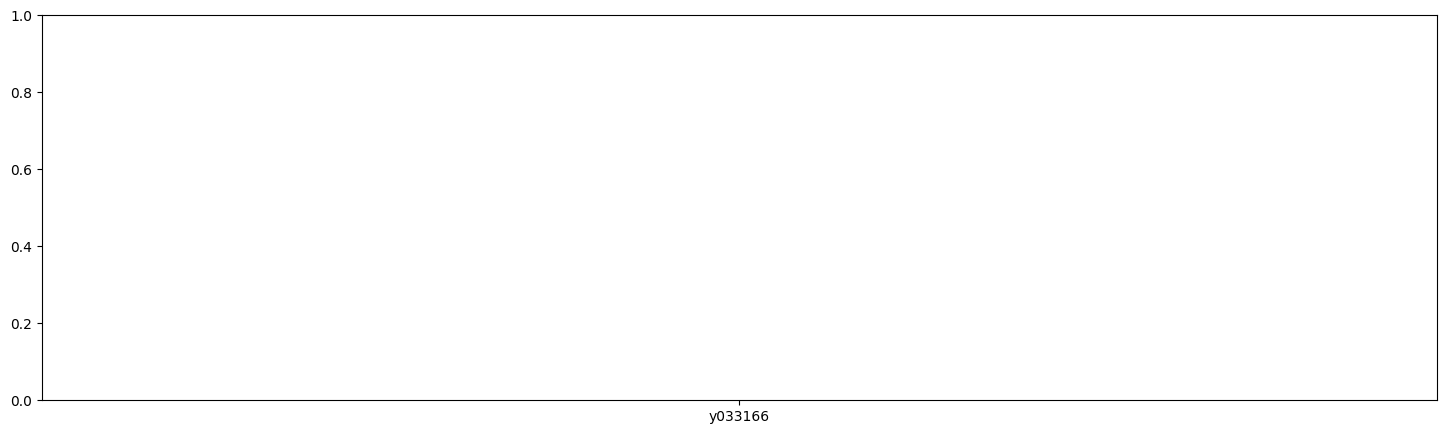

In [29]:

fig1, ax1 = plt.subplots(figsize=(18, 5))
bar_colors = id_counts_df['species'].map(species_color).fillna('#cccccc')
ax1.bar(id_counts_df['id'], id_counts_df['records'], color=bar_colors, edgecolor='none')
ax1.set_title('Records per ID (colored by species)')
ax1.set_xlabel('id')
ax1.set_ylabel('records')
ax1.grid(alpha=0.3, axis='y')
# Thin x tick labels
if len(id_counts_df) > 40:
    step = max(1, len(id_counts_df) // 40)
    ax1.set_xticks(np.arange(0, len(id_counts_df), step))
    ax1.set_xticklabels(id_counts_df['id'].iloc[::step], rotation=90, fontsize=8)
else:
    ax1.set_xticklabels(id_counts_df['id'], rotation=90, fontsize=8)
handles_spec = [
    plt.Line2D([0], [0], marker='s', linestyle='None',
               markerfacecolor=species_color.get(sp), color='none', label=sp)
    for sp in species_order
]
if handles_spec:
    ax1.legend(handles=handles_spec, title='species', frameon=False, ncol=len(handles_spec))
fig1.tight_layout()

# 2) Records per location with a series for each species
loc_spec = (
    df.groupby(['location', 'species'])
    .size()
    .unstack(fill_value=0)
    .loc[sorted(df['location'].unique())]
)
fig2, ax2 = plt.subplots(figsize=(18, 6))
loc_spec.plot(kind='bar', ax=ax2,
              color=[species_color.get(sp, '#999999') for sp in loc_spec.columns])
ax2.set_title('Records per location by species')
ax2.set_xlabel('location')
ax2.set_ylabel('records')
ax2.grid(alpha=0.3, axis='y')
ax2.legend(title='species', frameon=False)
ax2.tick_params(axis='x', rotation=90)
fig2.tight_layout()

# 3) Records by hour with a series for each species
hour_spec = (
    df.dropna(subset=['time_dt'])
    .assign(hour=df['time_dt'].dt.hour)
    .groupby(['hour', 'species']).size()
    .unstack(fill_value=0)
    .sort_index()
)
fig3, ax3 = plt.subplots(figsize=(12, 5))
for sp in hour_spec.columns:
    ax3.plot(hour_spec.index, hour_spec[sp], marker='o', ms=3,
             label=sp, color=species_color.get(sp, None))
ax3.set_title('Records by hour (per species)')
ax3.set_xlabel('hour of day')
ax3.set_ylabel('records')
ax3.set_xticks(range(0, 24))
ax3.grid(alpha=0.3)
ax3.legend(title='species', frameon=False, ncol=len(hour_spec.columns))
fig3.tight_layout()


counts = (
    df.dropna(subset=['time_dt'])
      .assign(day=df['time_dt'].dt.floor('D'),
              hour=df['time_dt'].dt.hour)
      .groupby(['species','day','hour']).size()
      .reset_index(name='records')
)
hourly_mean = (
    counts.groupby(['species','hour'])['records']
          .mean()
          .reset_index()
)

fig4, ax4 = plt.subplots(figsize=(14, 6))
for sp in species_order:
    spm = (hourly_mean[hourly_mean['species'] == sp]
           .set_index('hour')
           .reindex(range(24))['records'])
    if spm.notna().any():
        ax4.plot(spm.index, spm.values, marker='o', ms=3,
                 label=sp, color=species_color.get(sp, None))
ax4.set_title('mean records by hour (per species, averaged across days)')
ax4.set_xlabel('hour of day')
ax4.set_ylabel('mean records')
ax4.set_xticks(range(0, 24))
ax4.grid(alpha=0.3)
ax4.legend(title='species', frameon=False, ncol=len(species_order))
fig4.tight_layout()